In [1]:
# Import libraries which is required to analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset

df = pd.read_csv(r"C:\Users\Anshu\OneDrive\Desktop\AI Adoption & Layoff Risk Analysis\Data\Ai_Impact_jobs_Layoff_Risk_Dataset.csv")
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [3]:
# convert columns name into lowercase

df.columns = df.columns.str.lower()
df.columns.to_list()

['age',
 'education_level',
 'years_of_experience',
 'industry',
 'job_role',
 'company_size',
 'job_level',
 'routine_task_percentage',
 'creativity_requirement',
 'human_interaction_level',
 'ai_adoption_level',
 'number_of_ai_tools_used',
 'ai_usage_hours_per_week',
 'tasks_automated_percentage',
 'ai_training_hours',
 'layoff_risk']

# Step 1: ML Problem Definition

The Exploratory Data Analysis (EDA) identified several factors associated with employee layoff risk, including routine tasks, task automation, creativity requirements, and AI adoption. While these insights help explain historical patterns, they cannot predict the layoff risk of new employees.

To address this limitation, a supervised machine learning classification model will be developed to predict whether an employee belongs to the Low, Medium, or High layoff risk category based on employee, job, and AI-related characteristics. The model will help organizations identify high-risk roles early, support workforce planning, prioritize employee reskilling, and make informed decisions regarding AI adoption and job redesign.

# Step 2: Feature Selection
Before building any machine learning model, we need to decide which columns the model should use to make predictions. This process is called Feature Selection.

Feature Selection means choosing the useful columns that the model will learn from and removing unnecessary or irrelevant columns.
- In every supervised machine learning project, there are two types of variables:

    1. Input Features (X)---> These are the columns the model uses to learn patterns and make predictions.

    2. Target Variable (y)---> This is the column the model tries to predict.

In [4]:
# Input Features
X = df.drop('layoff_risk', axis=1)

# Target Variable
y = df['layoff_risk']

display(X.shape)
display(y.shape)

(20000, 15)

(20000,)

# Step 3: Data Preprocessing for ML
Data Preprocessing means converting raw data into a clean and machine-readable format before training the model.
- like...
    - Missing Values
    - Duplicates Records
    - Data Types
    - Outlier Analysis
    - Data Quality Checks
- We already completed most of the preprocessing during the EDA phase. Since the dataset is already clean, we do not repeat these steps.

# Step 4: Feature Engineering
Feature Engineering is the process of creating, transforming, or improving features to help a machine learning model learn patterns more effectively.

During EDA, we also found that the variables have meaningful relationships with the target variable
No additional feature engineering will be performed.

    - The dataset already contains meaningful and business-relevant features.
    - EDA confirmed that the existing features have significant relationships with the target variable.
    - There is no evidence that creating additional features would improve predictive performance.
    - Therefore, the existing features will be used directly for model development.

# Step 5: Train - Test Split
Train-Test Split is the process of dividing the dataset into training and testing subsets so that the model can be trained on one portion of the data and evaluated on another.

    - Training Data → The model learns patterns.
    - Testing Data → We check whether the model can make accurate predictions on new, unseen data.

In our dataset contains 20000 records. so we split the data into 80:20 ratio.
- Training Data contains 16000 records (80% of data)
- Testing Data contains 4000 records (20% of data)

The model learns from the 16,000 training records and is evaluated using the 4,000 unseen testing records.

In [5]:
# install library which we want for this train test split data
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training Features:', X_train.shape)
print('Testing Features :', X_test.shape)
print('Training Target  :', y_train.shape)
print('Testing Target   :', y_test.shape)

Training Features: (16000, 15)
Testing Features : (4000, 15)
Training Target  : (16000,)
Testing Target   : (4000,)


# Step 6: Encoding Categorical Variables
We know machine learning algorithms work with numbers, not text. So for that encoding is the process where we convert the categorical data into numerical format for machine learning models.

- But we also know that, the categorical values contain two types of data
    - Nominal ---> It doesn't given any order so for that we will convert that column into in One-Hot Encoding
    - Ordinal ---> It gives in a order format so for that we will convert that column into in Ordinal Encoding

In [6]:
category_columns = df.select_dtypes(include=['object', 'category']).columns.to_list()   # here we find the columns which we need to convert
category_columns

['education_level',
 'industry',
 'job_role',
 'company_size',
 'job_level',
 'ai_adoption_level',
 'layoff_risk']

In [7]:
for col in category_columns:
    print(f'\n{col}')
    print(df[col].unique())


education_level
["Master's" "Bachelor's" 'High School' 'PhD']

industry
['Finance' 'Manufacturing' 'Retail' 'Telecom' 'IT' 'Logistics'
 'Healthcare' 'Education']

job_role
['Accountant' 'Production Supervisor' 'Store Manager' 'Auditor'
 'Network Engineer' 'Software Engineer' 'ML Engineer' 'Inventory Analyst'
 'Dispatcher' 'Health Analyst' 'Support Specialist' 'Sales Associate'
 'Academic Coordinator' 'Financial Analyst' 'Operator'
 'Research Assistant' 'Quality Engineer' 'Teacher' 'Warehouse Manager'
 'Supply Chain Analyst' 'Operations Analyst' 'Medical Assistant' 'Nurse'
 'Data Analyst']

company_size
['Medium' 'Small' 'Large']

job_level
['Entry' 'Senior' 'Mid']

ai_adoption_level
['Medium' 'Low' 'High']

layoff_risk
['High' 'Low' 'Medium']


Observation:
- Industry and Job Role these two columns are not in ordinal category so for that we use here One-Hot Encoding. Otherwise, The remaining categorical columns have a natural order or hierarchy, so they will be encoded using Ordinal Encoding.

In [8]:
# install library which is used to convert category columns into numrical
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# define each of the categories order which is given in ordinal values 
education_order = [
    "High School",
    "Bachelor's",
    "Master's",
    "PhD"
]

company_size_order = [
    "Small",
    "Medium",
    "Large"
]

job_level_order = [
    "Entry",
    "Mid",
    "Senior",
    "Executive"
]

ai_adoption_order = [
    "Low",
    "Medium",
    "High"
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        education_order,
        company_size_order,
        job_level_order,
        ai_adoption_order
    ]
)

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

The ordinal and onehotencoder required this type of too long process, but there is one feature which is present in the scikit learn utility which is ColumnTransfrom.
- In production projects, we typically combine preprocessing steps using a ColumnTransformer (and often a Pipeline). This allows us to apply:
    - Ordinal Encoding to ordinal columns.
    - One-Hot Encoding to nominal columns.
    - Leave numerical columns unchanged.

This approach is cleaner, avoids manual mistakes, and scales well as projects grow.

### ColumnTransform
A ColumnTransformer is a Scikit-learn utility that allows us to apply different preprocessing techniques to different columns in a single step.

In [9]:
# install library which is required for this analysis
from sklearn.compose import ColumnTransformer

# create a ordinal column category
ordinal_features = [
    "education_level",
    "company_size",
    "job_level",
    "ai_adoption_level"
]

# create a nominal column category
nominal_features = [
    "industry",
    "job_role"
]


In [10]:
# create a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_encoder, ordinal_features),
        ("nominal", onehot_encoder, nominal_features)
    ],
    remainder="passthrough"
)

preprocessor

,transformers,"[('ordinal', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,"[['High School', ""Bachelor's"", ...], ['Small', 'Medium', ...], ...]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [11]:
# fit and transform
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(16000, 45)
(4000, 45)


# Step 7: Feature Scaling
Feature Scaling is the process of bringing numerical features to a similar range so that no single feature dominates the learning process because of its larger numerical values.

Feature scaling helps algorithms treat features more fairly. Common Feature Scaling Techniques

    1. Standardization (StandardScaler) Formula: z = (x−μ) / σ
        - It transforms data to have:
            Mean = 0
            Standard Deviation = 1
        - Best for:
            Logistic Regression
            Support Vector Machine (SVM)
            K-Nearest Neighbors (KNN)
            Neural Networks

    2. Normalization (MinMaxScaler) Formula: (x − xmin) / (xmax − xmin)
        - Transforms values into the range: 0 to 1
        - Best when the algorithm expects bounded inputs.

In [12]:
# install library which is used for Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)

X_test_scaled = scaler.transform(X_test_encoded)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16000, 45)
(4000, 45)




Now the question becomes: Which model should we start with?

# Step 8: Model Selection
Model Selection is the process of choosing suitable machine learning algorithms to solve the business problem and comparing their performance to identify the best-performing model.

No single machine learning algorithm performs best on every dataset. A model that performs well on one dataset may perform poorly on another. Therefore, instead of assuming which algorithm is the best, we train multiple models and compare their performance using evaluation metrics.

Our target variable is Layoff_Risk, which has three categories:

    Low
    Medium
    High

Therefore, this is a:

    Supervised Learning problem
    Classification problem
    Multiclass Classification problem

Since the target variable is categorical with three classes, we should use classification algorithms.

There are many classification algorithms available, such as:

    Logistic Regression
    Decision Tree
    Random Forest
    XGBoost
    LightGBM
    Support Vector Machine (SVM)
    K-Nearest Neighbors (KNN)

Although several algorithms are available, I selected only three models for this project because they provide a good balance between simplicity, interpretability, and predictive performance. By comparing these models, I can identify the most suitable algorithm for predicting employee layoff risk.

The selected models are:

    1. Logistic Regression
    2. Decision Tree
    3. Random Forest

# Step 9: Model Training & Model Evaluation
Model Training is the process of teaching a machine learning algorithm to learn the relationship between the input features (X) and the target variable (y) using the training dataset.

#### 1. Linear Regression

In [13]:
# import model library which is used in this analysis
from sklearn.linear_model import LogisticRegression

# create the model
log_model = LogisticRegression(random_state=42, max_iter=1000)

# train the model
log_model.fit(X_train_scaled, y_train)

# predict on the test set
y_pred_log = log_model.predict(X_test_scaled)

In [14]:
# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.93075
Precision: 0.9305712357152921
Recall: 0.93075
F1 Score: 0.9306455156941357

Classification Report:
               precision    recall  f1-score   support

        High       0.95      0.96      0.95      1360
         Low       0.94      0.94      0.94      1320
      Medium       0.90      0.89      0.89      1320

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000


Confusion Matrix:
 [[1302    0   58]
 [   0 1247   73]
 [  68   78 1174]]


Observation:
- The Logistic Regression model achieved an overall accuracy of 93.08%, demonstrating strong predictive performance in classifying employee layoff risk into Low, Medium, and High categories.
- The model showed balanced Precision, Recall, and F1-scores of approximately 93%, indicating reliable and consistent predictions across all classes.
- Performance was strongest for the High Risk category, while the Medium Risk category was comparatively more difficult to classify due to overlapping characteristics with the adjacent risk levels.
- The confusion matrix further revealed that the model almost never confused High Risk employees with Low Risk employees, with most misclassifications occurring only between neighboring categories (High ↔ Medium and Low ↔ Medium).
- Overall, the Logistic Regression model provides a strong and interpretable baseline for predicting employee layoff risk and serves as a benchmark for comparison with more advanced classification algorithms such as Decision Tree and Random Forest.

#### 2. Decision Tree Classifier

In [15]:
# import model library which is used in this analysis
from sklearn.tree import DecisionTreeClassifier

# create a model
dt_model = DecisionTreeClassifier(random_state=42)

# train the model
dt_model.fit(X_train_encoded, y_train)

# make prediction
y_pred_dt = dt_model.predict(X_test_encoded)

In [16]:
# already import the required model evaluation libraries

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.8397
Precision: 0.8393
Recall   : 0.8397
F1 Score : 0.8395

Classification Report:

              precision    recall  f1-score   support

        High       0.88      0.88      0.88      1360
         Low       0.87      0.88      0.88      1320
      Medium       0.76      0.75      0.76      1320

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000


Confusion Matrix:

[[1200    0  160]
 [   1 1167  152]
 [ 161  167  992]]


Observation:
- The Decision Tree model achieved an overall accuracy of 83.97%, with balanced Precision, Recall, and F1-scores of approximately 84%.
- The model performed well in identifying the High and Low layoff risk categories but showed noticeably weaker performance for the Medium risk category, which experienced the highest number of misclassifications.
- Compared with the Logistic Regression model, the Decision Tree produced lower predictive performance across all evaluation metrics.
- The reduced performance is likely due to the default Decision Tree overfitting the training data, resulting in poorer generalization to unseen employees. Despite its interpretability, the Decision Tree was not the best-performing baseline model for this dataset.

#### 3.Random Forest Classifier

In [17]:
# import model library which is used in this analysis
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_encoded, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_encoded)

In [18]:
# model evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8922
Precision: 0.8921
Recall   : 0.8922
F1 Score : 0.8922

Classification Report:

              precision    recall  f1-score   support

        High       0.92      0.93      0.92      1360
         Low       0.92      0.92      0.92      1320
      Medium       0.84      0.83      0.84      1320

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000


Confusion Matrix:

[[1260    0  100]
 [   0 1209  111]
 [ 115  105 1100]]


Observation:
- The Random Forest model achieved an overall accuracy of 89.22%, with balanced Precision, Recall, and F1-score values of approximately 89%.
- The model performed strongly in predicting the High and Low layoff risk categories while showing comparatively lower performance for the Medium Risk category due to overlapping characteristics with adjacent classes.
- The confusion matrix revealed that the model rarely confused the extreme classes (High and Low) and that most misclassifications occurred between Medium and its neighboring categories.
- Overall, the Random Forest model demonstrated strong predictive performance and better generalization than the Decision Tree, although it did not outperform the Logistic Regression model on this dataset.

### Hyperparameter Tuning
Hyperparameter Tuning is an optimization technique used to identify the best configuration of a machine learning algorithm. Instead of relying on default settings, different combinations of hyperparameters are evaluated to find the model that provides the highest predictive performance.

GridSearchCV
- GridSearchCV is a hyperparameter optimization technique that systematically evaluates every specified combination of hyperparameter values using cross-validation. I used it after selecting Logistic Regression as the best baseline model to identify the optimal hyperparameter configuration and verify whether the model's predictive performance could be improved before finalizing it.

In [19]:
# import library which is used to hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Build the Parameter Grid

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

# log the model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# aplly gridsearchcv
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# train gridsearchcv
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [20]:
# check best hyperparameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [21]:
# Best Cross Validation Score
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.9315625000000001


In [22]:
# Best Logistic Regression Model
best_log_model = grid_search.best_estimator_

In [23]:
# Predict on Test Data
y_pred_best = best_log_model.predict(X_test_scaled)

In [24]:
# Evaluate the Train Model
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9307
Precision: 0.9306
Recall   : 0.9307
F1 Score : 0.9306


In [25]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))


Classification Report:

              precision    recall  f1-score   support

        High       0.95      0.96      0.95      1360
         Low       0.94      0.94      0.94      1320
      Medium       0.90      0.89      0.89      1320

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



In [26]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_best))


Confusion Matrix:

[[1302    0   58]
 [   0 1247   73]
 [  68   78 1174]]


In [27]:
# Compare Baseline vs Tuned Model
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline Logistic Regression": [
        0.9308,
        0.9306,
        0.9308,
        0.9306
    ],
    "Tuned Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison.round(3)

,Metric,Baseline Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.931,0.931
1,Precision,0.931,0.931
2,Recall,0.931,0.931
3,F1 Score,0.931,0.931


Observation:
- Hyperparameter tuning was performed on the Logistic Regression model using GridSearchCV with 5-fold cross-validation.
- A total of 10 hyperparameter combinations were evaluated, resulting in 50 model fits. T
- he optimal configuration identified was C=1, penalty='l2', and solver='lbfgs', which matches the default settings of the Logistic Regression algorithm.
- The tuned model achieved a cross-validation accuracy of 93.16%, while the test accuracy remained 93.08%. Since the tuned model did not improve upon the baseline model, it can be concluded that the default hyperparameters were already optimal for this dataset.

# Step 10: Model Interpretation & Feature Importance

In [28]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Remove prefixes
feature_names = [name.split("__")[1] for name in feature_names]

print(feature_names)

['education_level', 'company_size', 'job_level', 'ai_adoption_level', 'industry_Education', 'industry_Finance', 'industry_Healthcare', 'industry_IT', 'industry_Logistics', 'industry_Manufacturing', 'industry_Retail', 'industry_Telecom', 'job_role_Academic Coordinator', 'job_role_Accountant', 'job_role_Auditor', 'job_role_Data Analyst', 'job_role_Dispatcher', 'job_role_Financial Analyst', 'job_role_Health Analyst', 'job_role_Inventory Analyst', 'job_role_ML Engineer', 'job_role_Medical Assistant', 'job_role_Network Engineer', 'job_role_Nurse', 'job_role_Operations Analyst', 'job_role_Operator', 'job_role_Production Supervisor', 'job_role_Quality Engineer', 'job_role_Research Assistant', 'job_role_Sales Associate', 'job_role_Software Engineer', 'job_role_Store Manager', 'job_role_Supply Chain Analyst', 'job_role_Support Specialist', 'job_role_Teacher', 'job_role_Warehouse Manager', 'age', 'years_of_experience', 'routine_task_percentage', 'creativity_requirement', 'human_interaction_level

In [29]:
# Get Logistic Regression Coefficients
coefficients = best_log_model.coef_

print(coefficients.shape)

(3, 45)


In [30]:
# Create DataFrame for Every Class
coef_df = pd.DataFrame(
    coefficients.T,
    index=feature_names,
    columns=best_log_model.classes_
)

coef_df.head()

,High,Low,Medium
education_level,-2.840891,2.823945,0.016946
company_size,0.021042,-0.018156,-0.002886
job_level,-4.612360,4.617174,-0.004815
ai_adoption_level,-0.221972,0.192512,0.029459
industry_Education,-1.024741,1.019657,0.005084


In [31]:
# Feature Importance for High Risk
high_coef = coef_df["High"].sort_values(ascending=False)
print(high_coef)

routine_task_percentage           4.809478
tasks_automated_percentage        4.322385
industry_Manufacturing            0.880046
industry_Retail                   0.660122
job_role_Operator                 0.542819
industry_Logistics                0.488176
job_role_Production Supervisor    0.474015
job_role_Quality Engineer         0.440171
job_role_Sales Associate          0.385745
job_role_Store Manager            0.367877
job_role_Inventory Analyst        0.340364
job_role_Supply Chain Analyst     0.326607
industry_Finance                  0.267565
job_role_Warehouse Manager        0.263343
job_role_Dispatcher               0.215866
job_role_Financial Analyst        0.171842
job_role_Auditor                  0.171285
job_role_Accountant               0.098390
number_of_ai_tools_used           0.079354
ai_usage_hours_per_week           0.077801
job_role_Network Engineer         0.060025
company_size                      0.021042
industry_Telecom                  0.010396
job_role_Su

In [32]:
# Top 10 Positive Features (High Risk)
top_high = high_coef.head(10)
print(top_high)

routine_task_percentage           4.809478
tasks_automated_percentage        4.322385
industry_Manufacturing            0.880046
industry_Retail                   0.660122
job_role_Operator                 0.542819
industry_Logistics                0.488176
job_role_Production Supervisor    0.474015
job_role_Quality Engineer         0.440171
job_role_Sales Associate          0.385745
job_role_Store Manager            0.367877
Name: High, dtype: float64


In [33]:
# Top 10 Positive Features (High Risk)
bottom_high = high_coef.tail(10)
print(bottom_high)

job_role_Teacher              -0.552823
job_role_Research Assistant   -0.593947
industry_Healthcare           -0.866385
industry_Education            -1.024741
ai_training_hours             -1.074836
years_of_experience           -1.609286
human_interaction_level       -2.120668
education_level               -2.840891
creativity_requirement        -3.356104
job_level                     -4.612360
Name: High, dtype: float64


In [34]:
# Repeat for Medium
medium_coef = coef_df["Medium"].sort_values(ascending=False)
print(medium_coef.head(10))
print(medium_coef.tail(10))

creativity_requirement        0.049836
routine_task_percentage       0.040120
job_role_Inventory Analyst    0.033542
ai_adoption_level             0.029459
job_role_Teacher              0.029105
age                           0.019318
job_role_Dispatcher           0.018546
education_level               0.016946
job_role_Quality Engineer     0.015542
industry_Retail               0.013956
Name: Medium, dtype: float64
industry_Logistics              -0.009076
industry_Finance                -0.014421
job_role_Auditor                -0.017324
job_role_Academic Coordinator   -0.017800
job_role_Operator               -0.022176
job_role_ML Engineer            -0.026555
job_role_Supply Chain Analyst   -0.033979
number_of_ai_tools_used         -0.036487
ai_training_hours               -0.049348
tasks_automated_percentage      -0.074742
Name: Medium, dtype: float64


In [35]:
# Repeat for low
low_coef = coef_df["Low"].sort_values(ascending=False)
print(low_coef.head(10))
print(low_coef.tail(10))

job_level                        4.617174
creativity_requirement           3.306268
education_level                  2.823945
human_interaction_level          2.120660
years_of_experience              1.603704
ai_training_hours                1.124185
industry_Education               1.019657
industry_Healthcare              0.858193
job_role_Research Assistant      0.597074
job_role_Academic Coordinator    0.568859
Name: Low, dtype: float64
job_role_Inventory Analyst       -0.373906
job_role_Sales Associate         -0.379166
job_role_Quality Engineer        -0.455713
job_role_Production Supervisor   -0.473417
industry_Logistics               -0.479100
job_role_Operator                -0.520643
industry_Retail                  -0.674079
industry_Manufacturing           -0.875349
tasks_automated_percentage       -4.247643
routine_task_percentage          -4.849598
Name: Low, dtype: float64


In [36]:
# Absolute Importance
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": abs(best_log_model.coef_).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance.head(20)

,Feature,Importance
0,routine_task_percentage,3.233065
1,job_level,3.078116
2,tasks_automated_percentage,2.881590
3,creativity_requirement,2.237403
4,education_level,1.893927
5,human_interaction_level,1.413779
6,years_of_experience,1.072857
7,ai_training_hours,0.749457
8,industry_Education,0.683161
9,industry_Manufacturing,0.586697


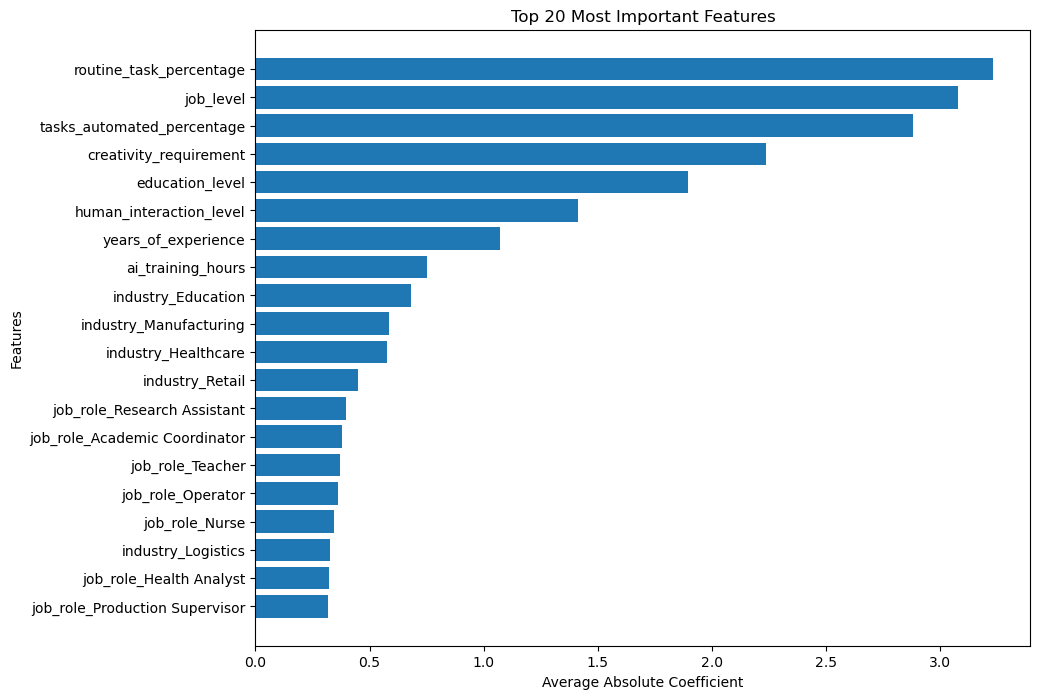

In [37]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.xlabel("Average Absolute Coefficient")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

Observation:
- Routine Task Percentage is the most important feature in predicting employee layoff risk.
- Job Level and Tasks Automated Percentage are the second and third most influential factors.
- Creativity Requirement, Education Level, and Human Interaction Level also play an important role in the model's predictions.
- Industry and specific job roles have a smaller impact compared to job-related characteristics.
- Overall, the model relies more on the nature of an employee's work than on their industry or job title when predicting layoff risk.

# Step 11: Class-wise Coefficient Interpretation

In [38]:
# Get coefficients for all classes
coef_df = pd.DataFrame(
    best_log_model.coef_.T,
    columns=best_log_model.classes_,
    index=feature_names
)

coef_df.round(3)

,High,Low,Medium
education_level,-2.841,2.824,0.017
company_size,0.021,-0.018,-0.003
job_level,-4.612,4.617,-0.005
ai_adoption_level,-0.222,0.193,0.029
industry_Education,-1.025,1.020,0.005
industry_Finance,0.268,-0.253,-0.014
industry_Healthcare,-0.866,0.858,0.008
industry_IT,-0.407,0.408,-0.001
industry_Logistics,0.488,-0.479,-0.009
industry_Manufacturing,0.880,-0.875,-0.005


In [39]:
# high risk interpretation
high_coef = (
    coef_df["High"]
    .sort_values(ascending=False)
    .reset_index()
)

high_coef.columns = ["Feature", "Coefficient"]

high_coef.round(3)

,Feature,Coefficient
0,routine_task_percentage,4.809
1,tasks_automated_percentage,4.322
2,industry_Manufacturing,0.880
3,industry_Retail,0.660
4,job_role_Operator,0.543
5,industry_Logistics,0.488
6,job_role_Production Supervisor,0.474
7,job_role_Quality Engineer,0.440
8,job_role_Sales Associate,0.386
9,job_role_Store Manager,0.368


Observation:
- Employees with a higher Routine Task Percentage and higher Tasks Automated Percentage are more likely to fall into the High layoff risk category.
- Employees working in Manufacturing, Retail, and Logistics industries show a higher probability of High layoff risk.
- Job roles such as Operator, Production Supervisor, Quality Engineer, and Sales Associate are more strongly associated with High layoff risk.
- Higher Creativity Requirement, Job Level, Education Level, Human Interaction Level, Years of Experience, and AI Training Hours reduce the likelihood of High layoff risk.


Business Insight
- Employees performing repetitive and highly automatable tasks are at the greatest risk of being replaced by AI, whereas employees with higher skills, greater creativity, more experience, and stronger human interaction requirements are less vulnerable to layoffs.

In [40]:
# medium risk interpretation
medium_coef = (
    coef_df["Medium"]
    .sort_values(ascending=False)
    .reset_index()
)

medium_coef.columns = ["Feature", "Coefficient"]

medium_coef.round(3)

,Feature,Coefficient
0,creativity_requirement,0.050
1,routine_task_percentage,0.040
2,job_role_Inventory Analyst,0.034
3,ai_adoption_level,0.029
4,job_role_Teacher,0.029
5,age,0.019
6,job_role_Dispatcher,0.019
7,education_level,0.017
8,job_role_Quality Engineer,0.016
9,industry_Retail,0.014


Observation:
- Most coefficients for the Medium class are very close to zero.
- This indicates that no single feature strongly distinguishes Medium-risk employees.
- Medium layoff risk appears to represent employees whose characteristics fall between the High and Low risk groups rather than having unique defining factors.

Business Insight
- Medium-risk employees represent a transition group. Their layoff risk depends on a combination of multiple factors rather than one dominant characteristic, making this class naturally more difficult for the model to distinguish.

In [41]:
# low risk interpretation
low_coef = (
    coef_df["Low"]
    .sort_values(ascending=False)
    .reset_index()
)

low_coef.columns = ["Feature", "Coefficient"]

low_coef.round(3)

,Feature,Coefficient
0,job_level,4.617
1,creativity_requirement,3.306
2,education_level,2.824
3,human_interaction_level,2.121
4,years_of_experience,1.604
5,ai_training_hours,1.124
6,industry_Education,1.020
7,industry_Healthcare,0.858
8,job_role_Research Assistant,0.597
9,job_role_Academic Coordinator,0.569


Observation:
- Higher Job Level is the strongest indicator of Low layoff risk.
- Employees with higher Creativity Requirement, Education Level, Human Interaction Level, and Years of Experience are more likely to belong to the Low layoff risk category.
- More AI Training Hours are also associated with lower layoff risk.
- Employees working in Education, Healthcare, and IT industries are more likely to have Low layoff risk.
- Higher Routine Task Percentage and Tasks Automated Percentage significantly reduce the probability of belonging to the Low layoff risk category.

Business Insight
- Employees performing creative, knowledge-intensive, and human-centric work with higher experience and continuous AI training are less likely to be affected by AI-driven layoffs.

#### Overall Business Finding
- Routine work and task automation are the strongest drivers of High layoff risk.
- Creativity, experience, education, human interaction, and AI training act as protective factors against layoffs.
- Employees in Education, Healthcare, and IT are generally less vulnerable than those in Manufacturing, Retail, and Logistics.
- The Medium risk category does not have strong unique characteristics and represents employees with mixed profiles.

# Step 12: Business Recommendations

### 1. Increase AI Training for Employees
- Provide regular AI training and upskilling programs so employees can adapt to new technologies and reduce their layoff risk.

### 2. Reduce Repetitive Work
- Identify jobs with a high percentage of routine tasks and redesign them by adding more creative and problem-solving responsibilities.

### 3. Focus on High-Risk Job Roles
- Pay special attention to employees working in roles with high automation potential, such as operators and production-related positions, and help them develop new skills.

### 4. Promote Creativity and Human Skills
- Encourage employees to strengthen skills such as creativity, communication, leadership, and critical thinking, as these are less likely to be replaced by AI.

### 5. Support High-Risk Industries
- Industries like Manufacturing, Retail, and Logistics should regularly assess employee skills and prepare reskilling programs before AI adoption increases.

### 6. Use Predictive Analytics for Workforce Planning
- Use machine learning models to identify employees who may be at higher layoff risk and make proactive decisions about training, reskilling, and workforce planning.

# Step 13: Project Conclusion
This project explored how AI adoption affects employee layoff risk by analyzing employee, job, and AI-related factors. The analysis showed that employees performing more routine and easily automated tasks are more likely to have a higher layoff risk. On the other hand, employees with higher education, more experience, greater creativity, stronger human interaction, and AI training are less likely to be affected by layoffs.

Three machine learning models were developed and compared, and Logistic Regression achieved the best performance with an accuracy of 93.1%. Hyperparameter tuning confirmed that the default model settings were already optimal for this dataset.

Overall, this project demonstrates how data analytics and machine learning can help organizations identify employees at higher layoff risk, support workforce planning, and make better decisions about employee training and reskilling. It also highlights the importance of developing future-ready skills to adapt to the growing use of AI in the workplace.

### Final Dataset Download

In [42]:
df.to_csv("final_ai_layoff_dataset.csv", index=False)
print("Final dataset exported successfully.")

Final dataset exported successfully.


In [43]:
final_dataset = pd.read_csv('final_ai_layoff_dataset.csv')
display(final_dataset.head())
display(final_dataset.shape)

,age,education_level,years_of_experience,industry,job_role,company_size,job_level,routine_task_percentage,creativity_requirement,human_interaction_level,ai_adoption_level,number_of_ai_tools_used,ai_usage_hours_per_week,tasks_automated_percentage,ai_training_hours,layoff_risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


(20000, 16)

## Preparing data for SQL Analysis

### Create a pipeline which connect python with postgresql

In [44]:
# install required libarary
# pip install sqlalchemy psycopg2

from sqlalchemy import create_engine

In [45]:
# create postgresql connection
username = "postgres"
password = "moto"
host = "localhost"
port = "5432"
database = "layoff_risk_analysis"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Test Connection
try:
    with engine.connect():
        print("PostgreSQL Connected Successfully!")
except Exception as e:
    print(e)

# Upload Dataset
df.to_sql(
    "employee_layoff_analysis",
    engine,
    if_exists="replace",
    index=False
)

print("Dataset Uploaded Successfully!")

# Verify Upload
query = "SELECT * FROM employee_layoff_analysis LIMIT 5;"
df_sql = pd.read_sql(query, engine)

df_sql.head()

PostgreSQL Connected Successfully!
Dataset Uploaded Successfully!


,age,education_level,years_of_experience,industry,job_role,company_size,job_level,routine_task_percentage,creativity_requirement,human_interaction_level,ai_adoption_level,number_of_ai_tools_used,ai_usage_hours_per_week,tasks_automated_percentage,ai_training_hours,layoff_risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium
